In [1]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import torch.nn as nn
import json
import os
import torchvision.models as models
import matplotlib.pyplot as plt

In [2]:
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(EnhancedCNN, self).__init__()
        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.6),  # Increased dropout to reduce overfitting
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EnhancedCNN()
model.load_state_dict(torch.load(r'../app/models/enhanced_model.pth', map_location=device))
model = model.to(device)  # Move model to the correct device
model.eval()

/tmp/ipykernel_70316/997643457.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r'../app/models/enhanced_model.pth', map_location=device

EnhancedCNN(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 3)  # 3 classes: asphalt, concrete, unpaved
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN()
model.load_state_dict(torch.load(r'../app/models/road_classifier.pth', map_location=device))
model = model.to(device)  # Move model to the correct device
model.eval()

/tmp/ipykernel_58038/3856019706.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r'../app/models/road_classifier.pth', map_location=devi

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [5]:
# Define the transformation for input images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

class_mapping = {0: 'asphalt', 1: 'concrete', 2: 'unpaved'}

def predict(folder_path):
    """Loops through a folder, predicts each image, prints results, and displays the image with its prediction."""
    if not os.path.exists(folder_path):
        print(f"Error: Folder '{folder_path}' does not exist.")
        return
    
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('jpg', 'png', 'jpeg'))][30:60]
    if not image_files:
        print(f"No image files found in '{folder_path}'.")
        return
    
    print("Processing images...")
    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        image = Image.open(image_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0)  # Add batch dimension
        
        with torch.no_grad():
            outputs = model(input_tensor.to(device))
            probabilities = torch.softmax(outputs, dim=1)
            predicted_class = torch.argmax(probabilities).item()
            confidence = probabilities[0][predicted_class].item()
        
        predicted_road_type = class_mapping[predicted_class]
        print(f"{image_file}: Predicted Road Type - {predicted_road_type}, Confidence - {confidence:.2f}")
        
        # Display the image with prediction
        plt.figure()
        plt.imshow(image)
        plt.title(f"{image_file}\n{predicted_road_type} ({confidence:.2f})")
        plt.axis("off")
        plt.show()

Processing images...
2022012621020811-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.68


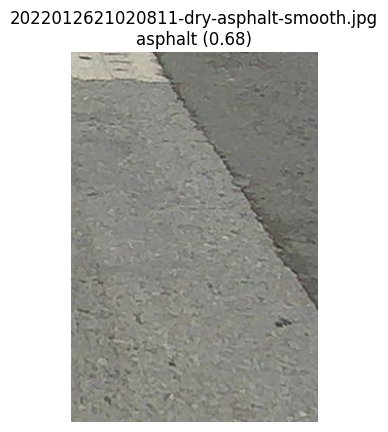

2022012621102216-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.61


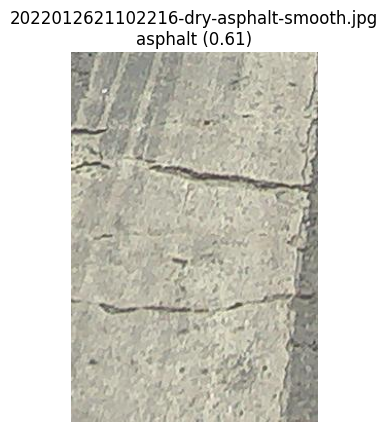

2022012621133410-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.99


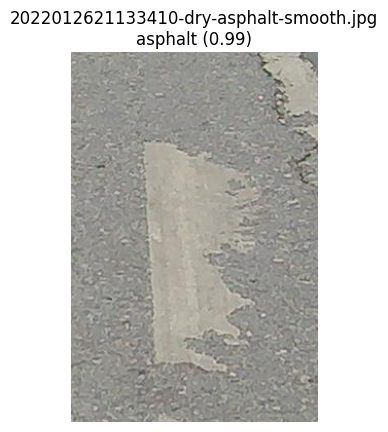

202201262114156-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.88


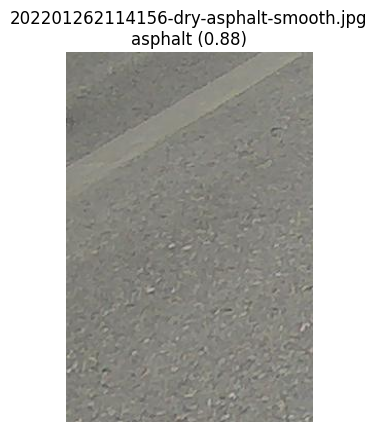

2022012621201211-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.96


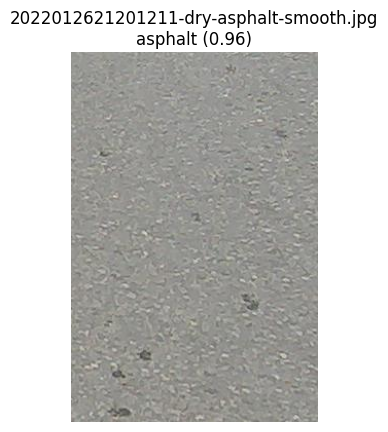

202201262131072-dry-concrete-severe.jpg: Predicted Road Type - asphalt, Confidence - 0.85


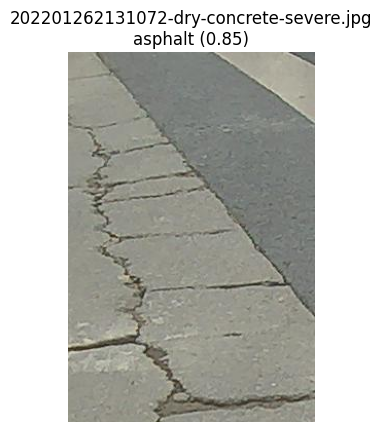

2022012621332418-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.97


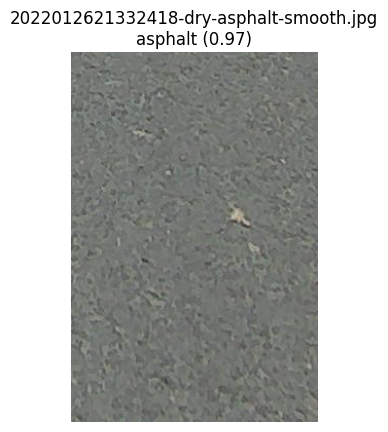

2022012621333812-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.72


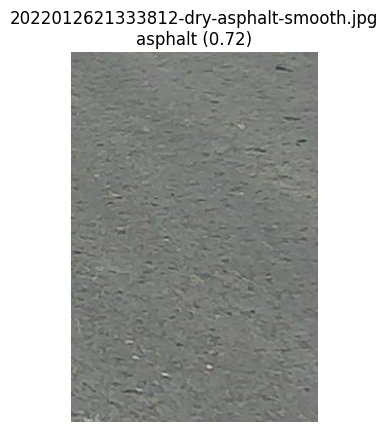

202201262156458-dry-concrete-slight.jpg: Predicted Road Type - concrete, Confidence - 0.95


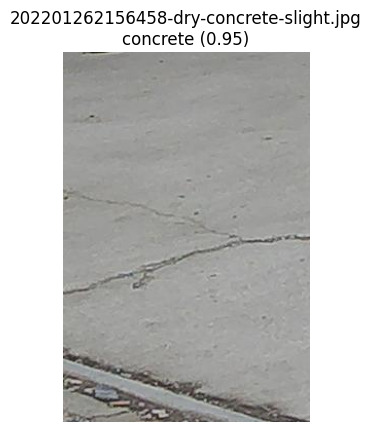

2022012621570413-dry-concrete-smooth.jpg: Predicted Road Type - concrete, Confidence - 0.98


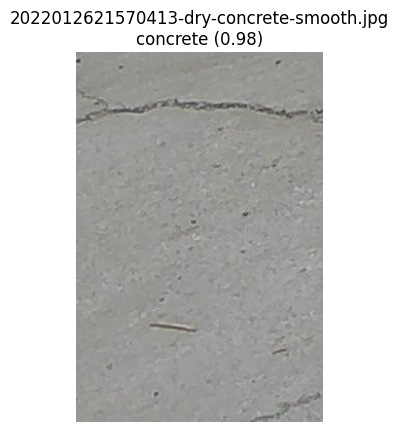

2022012622000113-dry-concrete-smooth.jpg: Predicted Road Type - concrete, Confidence - 0.91


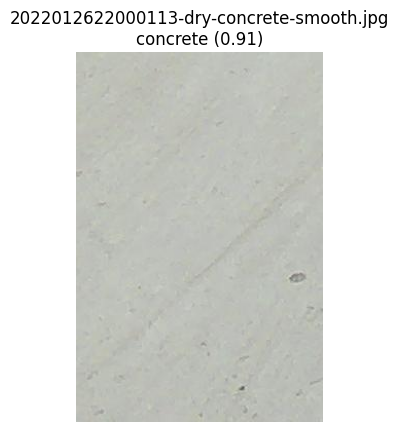

202201262200397-dry-concrete-smooth.jpg: Predicted Road Type - concrete, Confidence - 0.94


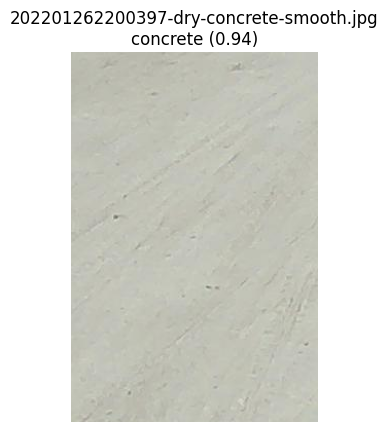

202201262202266-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.59


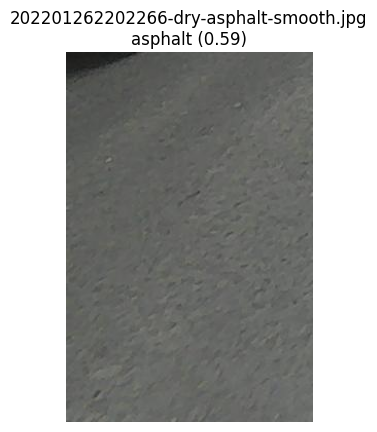

202201262206477-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.94


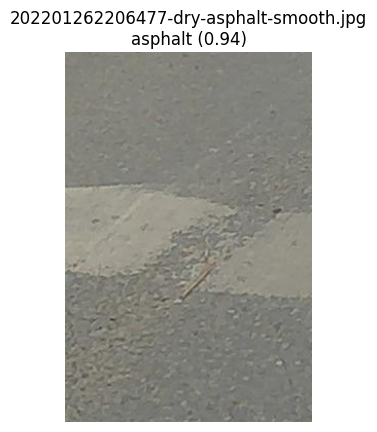

2022012622425711-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.95


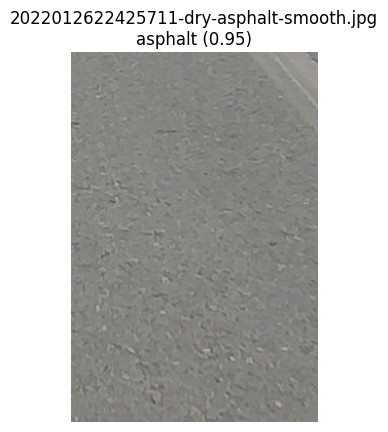

202201262243086-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.51


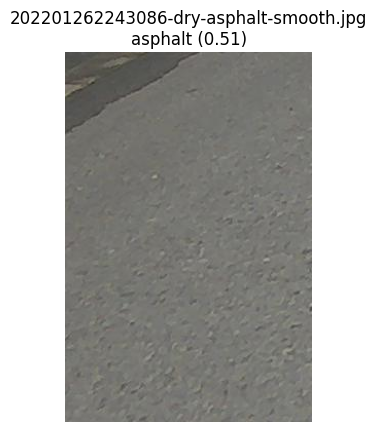

2022012622431116-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.91


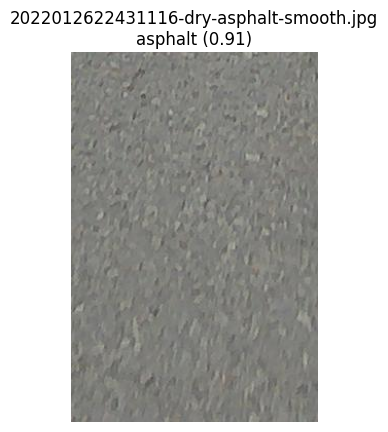

202201262244068-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.52


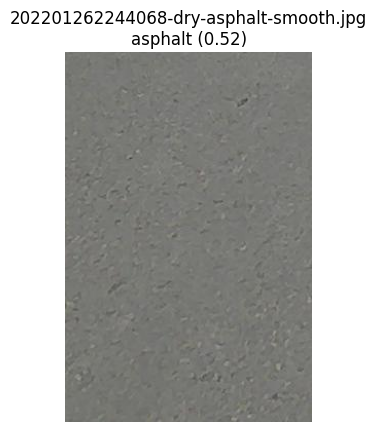

202201262249548-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.96


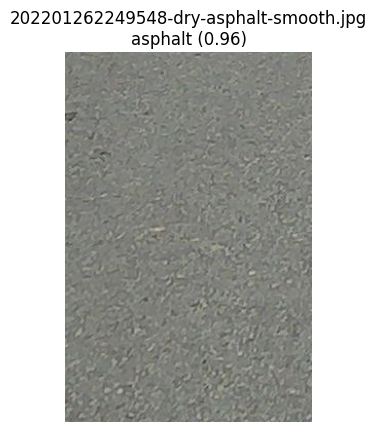

2022012622531313-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.97


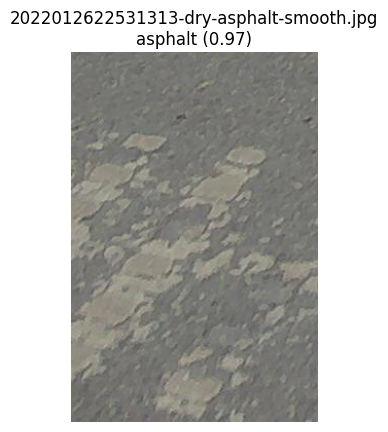

2022012622540418-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.98


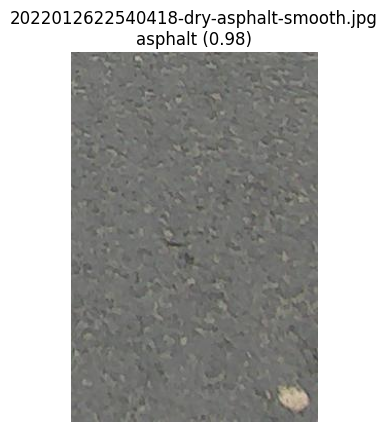

2022012623090817-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.88


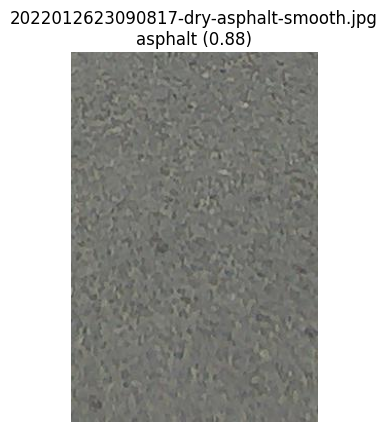

2022012623101211-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.85


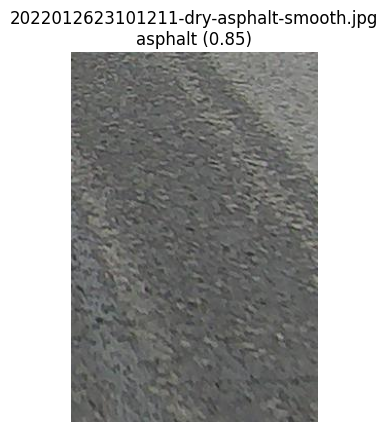

202201262310388-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.94


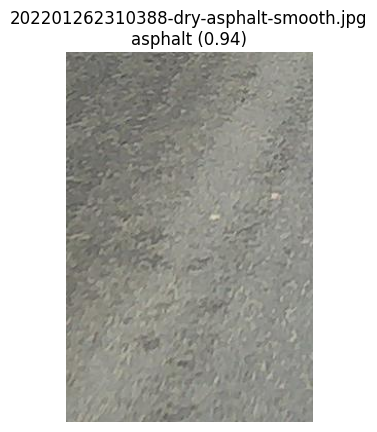

2022012623173312-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.98


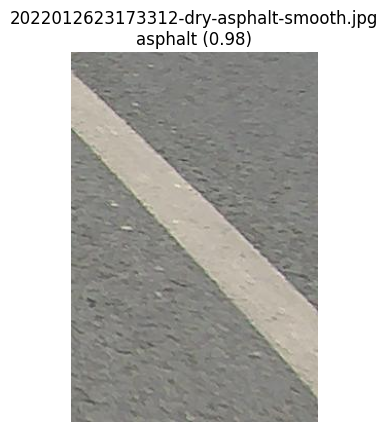

2022012623173314-dry-asphalt-smooth.jpg: Predicted Road Type - asphalt, Confidence - 0.97


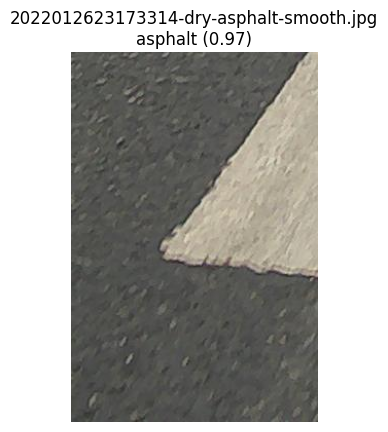

202201262320596-dry-asphalt-smooth.jpg: Predicted Road Type - concrete, Confidence - 0.61


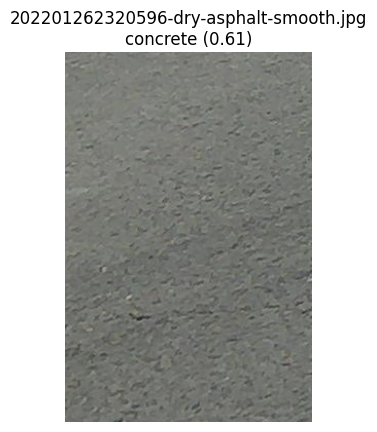

2022012623261218-dry-concrete-smooth.jpg: Predicted Road Type - concrete, Confidence - 0.95


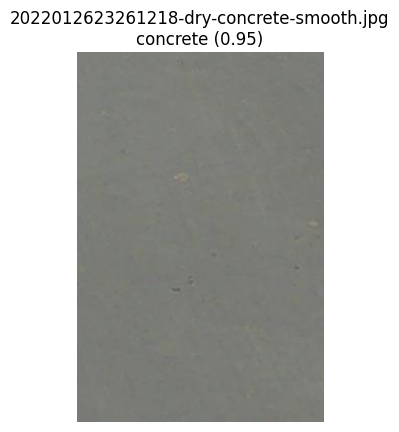

2022012623313416-dry-concrete-smooth.jpg: Predicted Road Type - concrete, Confidence - 0.67


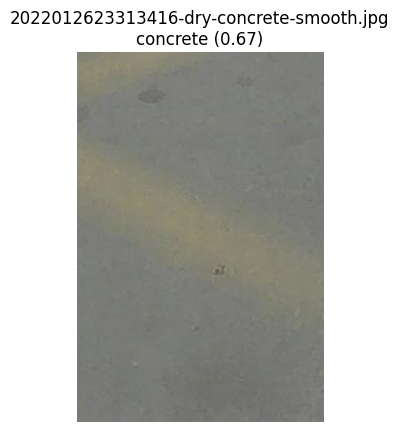

2022012623314218-dry-concrete-smooth.jpg: Predicted Road Type - concrete, Confidence - 0.52


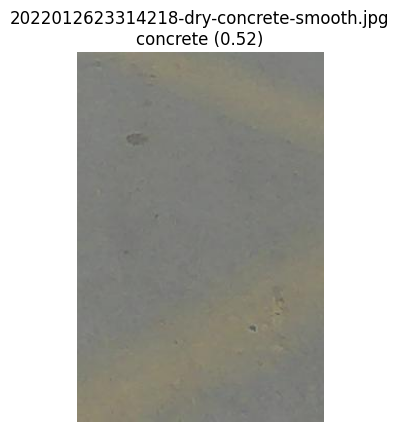

In [6]:
predict('/mnt/d/RSCD dataset-1million/RSCD dataset-1million/vali_20k')

In [8]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should return > 0
print(torch.cuda.current_device())  # Should return 0 (or another valid GPU index)
print(torch.cuda.get_device_name(0))  # Should return "NVIDIA RTX A4000 Laptop GPU"


True
1
0
NVIDIA RTX A4000 Laptop GPU
